# BeetleCast 09 — Where did mapped damage appear in 2022 versus 2023?

This notebook measures how spatially different the supplied 2022 and 2023
bark-beetle **mapped canopy-damage polygons** are.

It does **not** assume that 85% moved. It calculates the actual value.

The main reported statistic is:

> **Percentage of 2023 mapped-damage area and 50 m cells that do not overlap
> 2022 mapped damage.**

It also produces:

- side-by-side maps for 2022 and 2023;
- an overlap/change map;
- area- and patch-based statistics;
- nearest-distance statistics;
- a presentation-ready summary image.

## Important interpretation

These polygons are mapped canopy-damage observations, not individual beetles.
A different location in 2023 can reflect:

- newly mapped damage;
- changes in canopy condition;
- different survey/image footprints;
- or genuine spatial change.

Therefore, use wording such as:

> “X% of 2023 mapped damage occurred outside the 2022 mapped-damage footprint.”

Do **not** say that X% of beetles physically moved.


In [1]:
from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from rasterio.features import rasterize
from rasterio.transform import from_origin
from shapely.geometry import box

warnings.filterwarnings("ignore")

PATCH_SIZE_METRES = 50
REFERENCE_PERCENT = 85.0

cwd = Path.cwd()

if (cwd / "hackathon_data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "hackathon_data").exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "spatial_change"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_ROOT:", OUTPUT_ROOT)


PROJECT_ROOT: /Users/hemat/Desktop/hackathon-demo
OUTPUT_ROOT: /Users/hemat/Desktop/hackathon-demo/outputs/spatial_change


## 1. Strictly locate the bark-beetle labels and F3 AOI

The notebook rejects unrelated challenge AOIs such as vineyards.


In [2]:
LABEL_PATH_OVERRIDE = None
AOI_PATH_OVERRIDE = None

def normalised_name(path):
    return re.sub(r"[^a-z0-9]+", "", path.name.lower())

def is_bark_beetle_label(path):
    name = normalised_name(path)
    return (
        ("barkbeetle" in name or "barkbettle" in name)
        and "location" in name
        and "aoi" not in name
    )

def is_f3_bark_beetle_aoi(path):
    name = normalised_name(path)
    return (
        "f3" in name
        and ("barkbeetle" in name or "barkbettle" in name)
        and "aoi" in name
    )

search_roots = [
    PROJECT_ROOT,
    PROJECT_ROOT / "hackathon_data",
    PROJECT_ROOT / "hackathon_demo_data",
]

vector_paths = []

for root in search_roots:
    if root.exists():
        vector_paths.extend(root.rglob("*.geojson"))
        vector_paths.extend(root.rglob("*.gpkg"))
        vector_paths.extend(root.rglob("*.shp"))

vector_paths = sorted(set(path.resolve() for path in vector_paths))

if LABEL_PATH_OVERRIDE:
    LABEL_PATH = Path(LABEL_PATH_OVERRIDE).expanduser().resolve()
else:
    label_candidates = [
        path for path in vector_paths
        if is_bark_beetle_label(path)
    ]
    assert label_candidates, (
        "Could not find F3_bark_beetle_locations.geojson."
    )
    label_candidates = sorted(
        label_candidates,
        key=lambda path: (
            "processed" in str(path).lower(),
            path.suffix.lower() != ".geojson",
            len(str(path)),
        ),
    )
    LABEL_PATH = label_candidates[0]

if AOI_PATH_OVERRIDE:
    AOI_PATH = Path(AOI_PATH_OVERRIDE).expanduser().resolve()
else:
    aoi_candidates = [
        path for path in vector_paths
        if is_f3_bark_beetle_aoi(path)
    ]
    assert aoi_candidates, (
        "Could not find F3_Germany_BarkBeetle_aoi.geojson."
    )
    aoi_candidates = sorted(
        aoi_candidates,
        key=lambda path: (
            path.suffix.lower() != ".geojson",
            "(1)" in path.name,
            len(str(path)),
        ),
    )
    AOI_PATH = aoi_candidates[0]

assert is_bark_beetle_label(LABEL_PATH)
assert is_f3_bark_beetle_aoi(AOI_PATH)
assert "vineyard" not in normalised_name(AOI_PATH)
assert "chablis" not in normalised_name(AOI_PATH)

print("Label file:", LABEL_PATH)
print("F3 bark-beetle AOI:", AOI_PATH)


Label file: /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw/F3_bark_beetle_locations.geojson
F3 bark-beetle AOI: /Users/hemat/Desktop/hackathon-demo/hackathon_data/clean/F3_bark_beetle_labels_in_aoi.geojson


## 2. Load, validate, and clip the supplied labels

In [3]:
labels = gpd.read_file(LABEL_PATH)
aoi = gpd.read_file(AOI_PATH)

assert not labels.empty
assert not aoi.empty
assert labels.crs is not None
assert aoi.crs is not None
assert "tile_name" in labels.columns

labels = labels[
    labels.geometry.notna()
    & ~labels.geometry.is_empty
].copy()

aoi = aoi[
    aoi.geometry.notna()
    & ~aoi.geometry.is_empty
].copy()

labels["geometry"] = labels.geometry.make_valid()
aoi["geometry"] = aoi.geometry.make_valid()

labels["label_year"] = pd.to_numeric(
    labels["tile_name"]
    .astype(str)
    .str.extract(r"_rp_(20\d{2})_", expand=False),
    errors="coerce",
).astype("Int64")

assert labels["label_year"].notna().all()

available_years = sorted(
    labels["label_year"].astype(int).unique().tolist()
)

print("Raw label years:", available_years)
print(labels.groupby("label_year").size())

assert available_years == [2022, 2023], (
    f"Expected only 2022 and 2023, found {available_years}"
)

# Use a local UTM CRS for area and distance calculations.
analysis_crs = aoi.estimate_utm_crs()

labels_projected = labels.to_crs(analysis_crs)
aoi_projected = aoi.to_crs(analysis_crs)

aoi_union = aoi_projected.geometry.union_all()
assert not aoi_union.is_empty

labels_in_aoi = labels_projected[
    labels_projected.geometry.intersects(aoi_union)
].copy()

labels_in_aoi["geometry"] = (
    labels_in_aoi.geometry.intersection(aoi_union)
)

labels_in_aoi = labels_in_aoi[
    labels_in_aoi.geometry.notna()
    & ~labels_in_aoi.geometry.is_empty
].copy()

labels_in_aoi["area_ha_projected"] = (
    labels_in_aoi.geometry.area / 10_000
)

print()
print("Labels inside F3 AOI:")
print(labels_in_aoi.groupby("label_year").size())
print("Analysis CRS:", analysis_crs)


Raw label years: [2022, 2023]
label_year
2022     2413
2023    11945
dtype: int64

Labels inside F3 AOI:
label_year
2022    1583
2023    1431
dtype: int64
Analysis CRS: EPSG:32632


## 3. Dissolve each year into a mapped-damage footprint

This compares mapped polygon area, not polygon counts. Polygon counts can be
misleading because one damaged region may be split into many small features.


In [4]:
damage_2022 = labels_in_aoi[
    labels_in_aoi["label_year"] == 2022
].geometry.union_all()

damage_2023 = labels_in_aoi[
    labels_in_aoi["label_year"] == 2023
].geometry.union_all()

assert not damage_2022.is_empty
assert not damage_2023.is_empty

area_2022_m2 = damage_2022.area
area_2023_m2 = damage_2023.area

overlap_geometry = damage_2022.intersection(damage_2023)
overlap_m2 = overlap_geometry.area

only_2022_geometry = damage_2022.difference(damage_2023)
only_2023_geometry = damage_2023.difference(damage_2022)

only_2022_m2 = only_2022_geometry.area
only_2023_m2 = only_2023_geometry.area

union_geometry = damage_2022.union(damage_2023)
union_m2 = union_geometry.area

percent_2023_outside_2022 = (
    100 * only_2023_m2 / area_2023_m2
)

percent_2022_outside_2023 = (
    100 * only_2022_m2 / area_2022_m2
)

percent_overlap_of_2023 = (
    100 * overlap_m2 / area_2023_m2
)

jaccard_percent = (
    100 * overlap_m2 / union_m2
)

area_stats = pd.DataFrame([
    {
        "metric": "2022 mapped-damage area",
        "value_ha": area_2022_m2 / 10_000,
        "percent": np.nan,
    },
    {
        "metric": "2023 mapped-damage area",
        "value_ha": area_2023_m2 / 10_000,
        "percent": np.nan,
    },
    {
        "metric": "Overlapping mapped-damage area",
        "value_ha": overlap_m2 / 10_000,
        "percent": percent_overlap_of_2023,
    },
    {
        "metric": "2023 area outside 2022 damage",
        "value_ha": only_2023_m2 / 10_000,
        "percent": percent_2023_outside_2022,
    },
    {
        "metric": "2022 area outside 2023 damage",
        "value_ha": only_2022_m2 / 10_000,
        "percent": percent_2022_outside_2023,
    },
    {
        "metric": "Area Jaccard overlap",
        "value_ha": np.nan,
        "percent": jaccard_percent,
    },
])

display(area_stats)

print(
    f"{percent_2023_outside_2022:.1f}% of 2023 mapped-damage "
    "area lies outside the 2022 mapped-damage area."
)
print(
    f"{percent_overlap_of_2023:.1f}% of 2023 mapped-damage "
    "area overlaps the 2022 mapped-damage area."
)


,metric,value_ha,percent
0,2022 mapped-damage area,282.247336,NaN
1,2023 mapped-damage area,285.504031,NaN
2,Overlapping mapped-damage area,0.000000,0.0
3,2023 area outside 2022 damage,285.504031,100.0
4,2022 area outside 2023 damage,282.247336,100.0
5,Area Jaccard overlap,NaN,0.0


100.0% of 2023 mapped-damage area lies outside the 2022 mapped-damage area.
0.0% of 2023 mapped-damage area overlaps the 2022 mapped-damage area.


## 4. Repeat the comparison on a 50 m grid

This matches the approximate spatial unit used by the BeetleCast model.
A cell is positive when it touches a mapped-damage polygon.


In [5]:
minx, miny, maxx, maxy = aoi_union.bounds

width = int(np.ceil((maxx - minx) / PATCH_SIZE_METRES))
height = int(np.ceil((maxy - miny) / PATCH_SIZE_METRES))

grid_transform = from_origin(
    minx,
    maxy,
    PATCH_SIZE_METRES,
    PATCH_SIZE_METRES,
)

aoi_mask = rasterize(
    [(aoi_union, 1)],
    out_shape=(height, width),
    transform=grid_transform,
    fill=0,
    default_value=1,
    dtype="uint8",
    all_touched=True,
).astype(bool)

mask_2022 = rasterize(
    [(damage_2022, 1)],
    out_shape=(height, width),
    transform=grid_transform,
    fill=0,
    default_value=1,
    dtype="uint8",
    all_touched=True,
).astype(bool) & aoi_mask

mask_2023 = rasterize(
    [(damage_2023, 1)],
    out_shape=(height, width),
    transform=grid_transform,
    fill=0,
    default_value=1,
    dtype="uint8",
    all_touched=True,
).astype(bool) & aoi_mask

both_cells = mask_2022 & mask_2023
only_2022_cells = mask_2022 & ~mask_2023
only_2023_cells = mask_2023 & ~mask_2022

count_2022_cells = int(mask_2022.sum())
count_2023_cells = int(mask_2023.sum())
count_both_cells = int(both_cells.sum())
count_only_2022_cells = int(only_2022_cells.sum())
count_only_2023_cells = int(only_2023_cells.sum())

percent_2023_cells_new_location = (
    100 * count_only_2023_cells / count_2023_cells
)

percent_2023_cells_overlap = (
    100 * count_both_cells / count_2023_cells
)

cell_stats = pd.DataFrame([
    {
        "cell_category": "2022 mapped-damage cells",
        "cell_count": count_2022_cells,
        "percent_of_2023_cells": np.nan,
    },
    {
        "cell_category": "2023 mapped-damage cells",
        "cell_count": count_2023_cells,
        "percent_of_2023_cells": 100.0,
    },
    {
        "cell_category": "Both 2022 and 2023",
        "cell_count": count_both_cells,
        "percent_of_2023_cells": percent_2023_cells_overlap,
    },
    {
        "cell_category": "2023 only",
        "cell_count": count_only_2023_cells,
        "percent_of_2023_cells": percent_2023_cells_new_location,
    },
    {
        "cell_category": "2022 only",
        "cell_count": count_only_2022_cells,
        "percent_of_2023_cells": np.nan,
    },
])

display(cell_stats)

print(
    f"{percent_2023_cells_new_location:.1f}% of 2023 positive "
    "50 m cells were not positive in 2022."
)


,cell_category,cell_count,percent_of_2023_cells
0,2022 mapped-damage cells,2612,NaN
1,2023 mapped-damage cells,2550,100.000000
2,Both 2022 and 2023,16,0.627451
3,2023 only,2534,99.372549
4,2022 only,2596,NaN


99.4% of 2023 positive 50 m cells were not positive in 2022.


## 5. Distance from each 2023 polygon to the nearest 2022 mapped damage

A distance of zero means the 2023 polygon touches or overlaps the dissolved
2022 mapped-damage geometry.


In [6]:
labels_2023 = labels_in_aoi[
    labels_in_aoi["label_year"] == 2023
].copy()

labels_2023["distance_to_2022_m"] = (
    labels_2023.geometry.distance(damage_2022)
)

distance_thresholds = [0, 50, 100, 250, 500, 1000]

distance_rows = []

for threshold in distance_thresholds:
    if threshold == 0:
        share = (
            100
            * (labels_2023["distance_to_2022_m"] > 0).mean()
        )
        label = "More than 0 m from 2022 damage"
    else:
        share = (
            100
            * (
                labels_2023["distance_to_2022_m"]
                > threshold
            ).mean()
        )
        label = f"More than {threshold} m from 2022 damage"

    distance_rows.append({
        "distance_test": label,
        "percent_of_2023_polygons": share,
    })

distance_stats = pd.DataFrame(distance_rows)

display(distance_stats)

print(
    "Median nearest distance:",
    f"{labels_2023['distance_to_2022_m'].median():.1f} m",
)
print(
    "90th percentile nearest distance:",
    f"{labels_2023['distance_to_2022_m'].quantile(0.90):.1f} m",
)


,distance_test,percent_of_2023_polygons
0,More than 0 m from 2022 damage,99.091544
1,More than 50 m from 2022 damage,98.951782
2,More than 100 m from 2022 damage,97.903564
3,More than 250 m from 2022 damage,93.570929
4,More than 500 m from 2022 damage,87.840671
5,More than 1000 m from 2022 damage,74.074074


Median nearest distance: 1972.1 m
90th percentile nearest distance: 3461.3 m


## 6. Create maps of the two years and their overlap

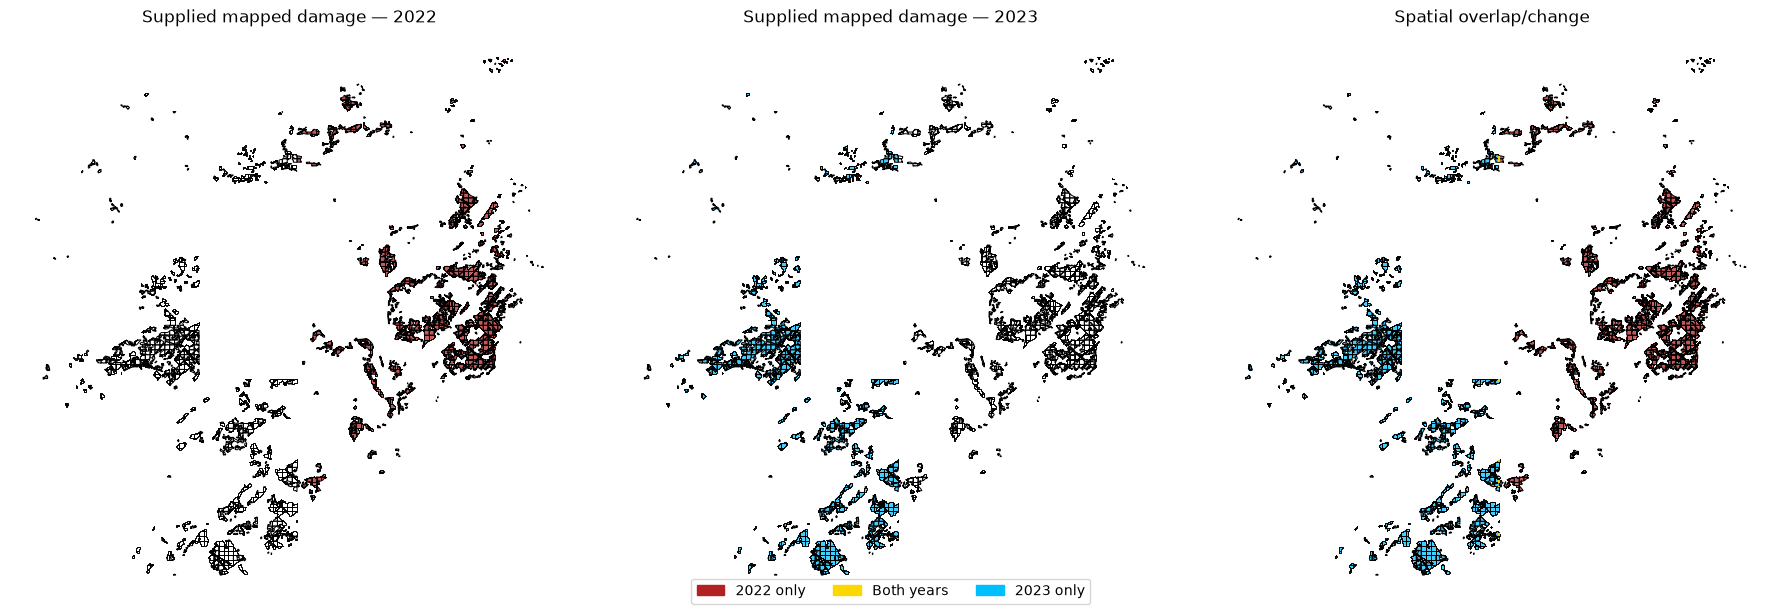

Saved: /Users/hemat/Desktop/hackathon-demo/outputs/spatial_change/mapped_damage_2022_2023_overlap.png


In [7]:
year_2022_gdf = gpd.GeoDataFrame(
    {"year": [2022]},
    geometry=[damage_2022],
    crs=analysis_crs,
)

year_2023_gdf = gpd.GeoDataFrame(
    {"year": [2023]},
    geometry=[damage_2023],
    crs=analysis_crs,
)

only_2022_gdf = gpd.GeoDataFrame(
    {"category": ["2022 only"]},
    geometry=[only_2022_geometry],
    crs=analysis_crs,
)

overlap_gdf = gpd.GeoDataFrame(
    {"category": ["Both years"]},
    geometry=[overlap_geometry],
    crs=analysis_crs,
)

only_2023_gdf = gpd.GeoDataFrame(
    {"category": ["2023 only"]},
    geometry=[only_2023_geometry],
    crs=analysis_crs,
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
    constrained_layout=True,
)

aoi_projected.boundary.plot(
    ax=axes[0],
    color="black",
    linewidth=0.7,
)
year_2022_gdf.plot(
    ax=axes[0],
    color="firebrick",
    alpha=0.75,
)
axes[0].set_title("Supplied mapped damage — 2022")
axes[0].axis("off")

aoi_projected.boundary.plot(
    ax=axes[1],
    color="black",
    linewidth=0.7,
)
year_2023_gdf.plot(
    ax=axes[1],
    color="deepskyblue",
    alpha=0.75,
)
axes[1].set_title("Supplied mapped damage — 2023")
axes[1].axis("off")

aoi_projected.boundary.plot(
    ax=axes[2],
    color="black",
    linewidth=0.7,
)

if not only_2022_geometry.is_empty:
    only_2022_gdf.plot(
        ax=axes[2],
        color="firebrick",
        alpha=0.75,
    )

if not overlap_geometry.is_empty:
    overlap_gdf.plot(
        ax=axes[2],
        color="gold",
        alpha=0.95,
    )

if not only_2023_geometry.is_empty:
    only_2023_gdf.plot(
        ax=axes[2],
        color="deepskyblue",
        alpha=0.75,
    )

axes[2].set_title("Spatial overlap/change")
axes[2].axis("off")

legend_handles = [
    mpatches.Patch(
        color="firebrick",
        label="2022 only",
    ),
    mpatches.Patch(
        color="gold",
        label="Both years",
    ),
    mpatches.Patch(
        color="deepskyblue",
        label="2023 only",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=True,
)

map_path = OUTPUT_ROOT / "mapped_damage_2022_2023_overlap.png"

plt.savefig(
    map_path,
    dpi=240,
    bbox_inches="tight",
)
plt.show()

print("Saved:", map_path)


## 7. Create a presentation-ready statistics figure

The dashed line marks the proposed 85% statement. The bars show the actual
calculated values.


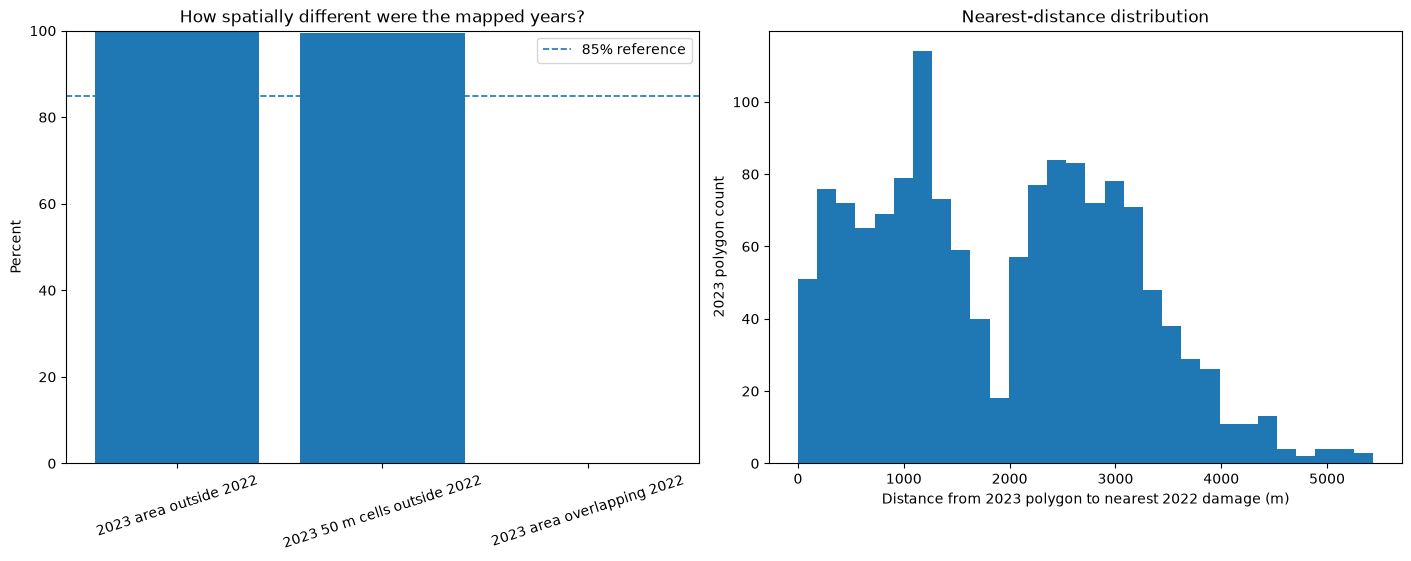

Saved: /Users/hemat/Desktop/hackathon-demo/outputs/spatial_change/mapped_damage_spatial_change_statistics.png


In [8]:
headline_metrics = pd.DataFrame({
    "metric": [
        "2023 area outside 2022",
        "2023 50 m cells outside 2022",
        "2023 area overlapping 2022",
    ],
    "percent": [
        percent_2023_outside_2022,
        percent_2023_cells_new_location,
        percent_overlap_of_2023,
    ],
})

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.5),
    constrained_layout=True,
)

axes[0].bar(
    headline_metrics["metric"],
    headline_metrics["percent"],
)
axes[0].axhline(
    REFERENCE_PERCENT,
    linestyle="--",
    linewidth=1.2,
    label="85% reference",
)
axes[0].set_ylim(0, 100)
axes[0].set_ylabel("Percent")
axes[0].set_title("How spatially different were the mapped years?")
axes[0].tick_params(axis="x", rotation=18)
axes[0].legend()

axes[1].hist(
    labels_2023["distance_to_2022_m"],
    bins=30,
)
axes[1].set_xlabel(
    "Distance from 2023 polygon to nearest 2022 damage (m)"
)
axes[1].set_ylabel("2023 polygon count")
axes[1].set_title("Nearest-distance distribution")

stats_figure_path = (
    OUTPUT_ROOT
    / "mapped_damage_spatial_change_statistics.png"
)

plt.savefig(
    stats_figure_path,
    dpi=240,
    bbox_inches="tight",
)
plt.show()

print("Saved:", stats_figure_path)


## 8. Check whether the “85%” claim is supported

The notebook uses a tolerance of ±2 percentage points.


In [9]:
TOLERANCE_PERCENTAGE_POINTS = 2.0

area_matches_85 = (
    abs(
        percent_2023_outside_2022
        - REFERENCE_PERCENT
    )
    <= TOLERANCE_PERCENTAGE_POINTS
)

cells_match_85 = (
    abs(
        percent_2023_cells_new_location
        - REFERENCE_PERCENT
    )
    <= TOLERANCE_PERCENTAGE_POINTS
)

print("85% CLAIM CHECK")
print("---------------")
print(
    "Area-based non-overlap:",
    f"{percent_2023_outside_2022:.1f}%",
)
print(
    "50 m cell-based non-overlap:",
    f"{percent_2023_cells_new_location:.1f}%",
)
print()

if area_matches_85 or cells_match_85:
    print(
        "The data supports an approximately 85% non-overlap "
        "statement under at least one spatial definition."
    )
else:
    print(
        "The calculated result is not approximately 85%. "
        "Use the actual computed percentage instead."
    )

print()
print("Recommended wording:")
print(
    f"'{percent_2023_cells_new_location:.1f}% of 2023 mapped-damage "
    "50 m cells did not overlap mapped damage from 2022.'"
)
print()
print(
    "Caution: this demonstrates spatial non-overlap of supplied "
    "mapped damage, not physical beetle movement."
)


85% CLAIM CHECK
---------------
Area-based non-overlap: 100.0%
50 m cell-based non-overlap: 99.4%

The calculated result is not approximately 85%. Use the actual computed percentage instead.

Recommended wording:
'99.4% of 2023 mapped-damage 50 m cells did not overlap mapped damage from 2022.'

Caution: this demonstrates spatial non-overlap of supplied mapped damage, not physical beetle movement.


## 9. Export all statistics and a short audit report

In [10]:
area_stats_path = OUTPUT_ROOT / "area_overlap_statistics.csv"
cell_stats_path = OUTPUT_ROOT / "cell_overlap_statistics.csv"
distance_stats_path = OUTPUT_ROOT / "nearest_distance_statistics.csv"
polygon_distances_path = (
    OUTPUT_ROOT
    / "2023_polygon_distance_to_2022.csv"
)

area_stats.to_csv(area_stats_path, index=False)
cell_stats.to_csv(cell_stats_path, index=False)
distance_stats.to_csv(distance_stats_path, index=False)

labels_2023[
    [
        "tile_name",
        "area_ha_projected",
        "distance_to_2022_m",
    ]
].to_csv(
    polygon_distances_path,
    index=False,
)

report = {
    "label_file": str(LABEL_PATH),
    "aoi_file": str(AOI_PATH),
    "analysis_crs": str(analysis_crs),
    "raw_label_years": available_years,
    "percent_2023_area_outside_2022": (
        float(percent_2023_outside_2022)
    ),
    "percent_2023_cells_outside_2022": (
        float(percent_2023_cells_new_location)
    ),
    "percent_2023_area_overlapping_2022": (
        float(percent_overlap_of_2023)
    ),
    "area_jaccard_percent": float(jaccard_percent),
    "median_2023_polygon_distance_to_2022_m": float(
        labels_2023["distance_to_2022_m"].median()
    ),
    "approximately_85_percent_supported": bool(
        area_matches_85 or cells_match_85
    ),
    "recommended_claim": (
        f"{percent_2023_cells_new_location:.1f}% of 2023 "
        "mapped-damage 50 m cells did not overlap mapped "
        "damage from 2022."
    ),
    "limitation": (
        "The result measures non-overlap in mapped canopy-damage "
        "locations. It does not prove physical movement of beetles, "
        "and different survey footprints may contribute."
    ),
}

report_path = OUTPUT_ROOT / "spatial_change_audit_report.json"

with open(report_path, "w") as handle:
    json.dump(report, handle, indent=2)

print("Saved:")
for path in [
    area_stats_path,
    cell_stats_path,
    distance_stats_path,
    polygon_distances_path,
    report_path,
]:
    print("-", path)


Saved:
- /Users/hemat/Desktop/hackathon-demo/outputs/spatial_change/area_overlap_statistics.csv
- /Users/hemat/Desktop/hackathon-demo/outputs/spatial_change/cell_overlap_statistics.csv
- /Users/hemat/Desktop/hackathon-demo/outputs/spatial_change/nearest_distance_statistics.csv
- /Users/hemat/Desktop/hackathon-demo/outputs/spatial_change/2023_polygon_distance_to_2022.csv
- /Users/hemat/Desktop/hackathon-demo/outputs/spatial_change/spatial_change_audit_report.json


## 10. Final summary

In [11]:
print("SPATIAL CHANGE AUDIT COMPLETE")
print("-----------------------------")
print(
    f"2023 mapped area outside 2022 mapped area: "
    f"{percent_2023_outside_2022:.1f}%"
)
print(
    f"2023 positive 50 m cells outside 2022 cells: "
    f"{percent_2023_cells_new_location:.1f}%"
)
print(
    f"2023 mapped area overlapping 2022: "
    f"{percent_overlap_of_2023:.1f}%"
)
print(
    f"Area Jaccard overlap: {jaccard_percent:.1f}%"
)
print(
    "Median 2023-to-2022 nearest distance:",
    f"{labels_2023['distance_to_2022_m'].median():.1f} m",
)
print()
print(
    "Use the actual computed result, not a hard-coded 85%."
)
print(
    "Describe it as mapped-damage spatial non-overlap, "
    "not beetle movement."
)


SPATIAL CHANGE AUDIT COMPLETE
-----------------------------
2023 mapped area outside 2022 mapped area: 100.0%
2023 positive 50 m cells outside 2022 cells: 99.4%
2023 mapped area overlapping 2022: 0.0%
Area Jaccard overlap: 0.0%
Median 2023-to-2022 nearest distance: 1972.1 m

Use the actual computed result, not a hard-coded 85%.
Describe it as mapped-damage spatial non-overlap, not beetle movement.
